# 3c — Similarity Sweeps (v3.0)

Joint σ + K optimisation for the **Similarity model** via a single Optuna TPE study.

| § | Stage | Description | Est. wall time |
|---|---|---|---|
| 2 | **Joint Optuna** | Per-feature σ + K — 23-parameter TPE | 1–2 h |
| 3 | **Evaluate & decide** | LOO ablation; choose `obs_sel` for JSON | ~30 min |
| 4 | **Write JSON** | Save best params + selected features | < 1 s |

Outputs → `output/sweeps/sim_joint_results.csv` | `output/sweeps/sim_best_params.json`

**Kernel:** \( w(x_t, x_r) = \exp\!\left(-\tfrac{1}{2} \overline{\left(\frac{x_t - x_r}{\sigma_f}\right)^2}\right) \)

## 0. Toggles

In [ ]:
from config import N_OPTUNA_TRIALS  # config-derived default; kept self-sufficient so this cell can run first

RUN_JOINT_OPTUNA = True   # set False to reload from existing sim_joint_results.csv

# These are used in §1c and §2 — defined here so they are always set first
SIM_KERNEL      = 'rbf'
SIM_WEIGHT_MODE = 'shifted_exp'

N_OPTUNA_JOINT = N_OPTUNA_TRIALS 
K_JOINT_LO     = 3.0
K_JOINT_HI     = 15.0

✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36


## 1. Imports & setup

In [15]:
import sys, json, time, warnings, platform, psutil, datetime
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from config import *

optuna.logging.set_verbosity(optuna.logging.WARNING)

sweep_dir.mkdir(parents=True, exist_ok=True)
(fig_root / 'sweeps').mkdir(parents=True, exist_ok=True)
fig_sweep = fig_root / 'sweeps'

print(f'sweep_dir : {sweep_dir}')
print(f'fig_sweep : {fig_sweep}')

sweep_dir : output/sweeps
fig_sweep : fig/sweeps


### 1a. Verify parquet

In [16]:
df_check  = pd.read_parquet(parquet_ref, columns=obs_model + ['q'])
missing_m = [c for c in obs_model if c not in df_check.columns]
all_nan_m = [c for c in obs_model if df_check[c].isna().all()]
assert not missing_m, f'MISSING from parquet: {missing_m}'
assert not all_nan_m, f'ALL-NaN columns: {all_nan_m}'
print(f'\u2713 {len(obs_model)} obs_model features verified | q_clip_max={q_clip_max}')

✓ 21 obs_model features verified | q_clip_max=0.35


### 1b. Load reference data

In [17]:
# obs_sel here = the CANDIDATE feature universe fed into the sweep (edit to test a
# different universe). The FINAL selected subset is written to the sweep JSON under
# the 'obs_sel' key and is what 4x/5x load — this line does not set the final list.
obs_sel = obs_sweep

df_ref    = pd.read_parquet(parquet_ref)
available = [f for f in obs_sel if f in df_ref.columns]
missing   = [f for f in obs_sel if f not in df_ref.columns]
if missing:
    warnings.warn(f'obs_sel columns missing from parquet: {missing}')
    raise RuntimeError(f'Missing features: {missing}')

cols_needed = available + ['q', 'lat', 'lon']
if 'weight' in df_ref.columns:
    cols_needed.append('weight')

work = (df_ref[cols_needed]
        .replace([np.inf, -np.inf], np.nan)
        .dropna())
work = work[(work['q'] >= q_clip_min) & (work['q'] <= q_clip_max)]

y_sim = work['q'].values.astype(np.float32)
w_sim = work['weight'].values.astype(np.float32) if 'weight' in work.columns \
        else np.ones(len(work), dtype=np.float32)
X_sim = work[available].values.astype(np.float32)

print(f'Reference rows : {len(work):,}')
print(f'Features       : {len(available)}')
print(available)

Reference rows : 30,847
Features       : 22
['SEDIMENT', 'LITH_RHO', 'CTD', 'REVEAL_S80', 'REVEAL_P150', 'MAG_SEIS_MOHO', 'REVEAL_S70', 'REVEAL_S100', 'REVEAL_VP60VS70', 'BOUGUER', 'MOHO_GRAV', 'REVEAL_VP50VS80', 'GEOID', 'MOHO', 'FREE_AIR', 'CRUST_RHO', 'SI', 'LAB', 'EMAG2_LOG', 'REVEAL_S90', 'REVEAL_VP90VS60', 'DEM']


### 1c. CV folds + similarity helper

In [18]:
from lib.similarity import (
    prepare_sigma, standardise_features,
    similarity_sweep, similarity_predict,
    spatial_block_kfold
)

# v0_5 #6: spatial block CV instead of random KFold(shuffle=True). Random folds
# leak through spatial autocorrelation of lat/lon-correlated features (DEM,
# GEOID, gravity), inflating CV R2. spatial_block_kfold gives a realistic
# estimate of generalisation to unsampled regions. lat/lon come from `work`.
fold_splits = spatial_block_kfold(
    work['lat'].values, work['lon'].values,
    n_splits=CV_FOLDS_SIM, random_state=random_state)

print(f'Similarity mode: kernel={SIM_KERNEL} | weight_mode={SIM_WEIGHT_MODE}')


def sim_cv_r2(X_raw, y, sigma_arr, K, fold_splits, w=None):
    """
    CV R² via similarity_predict (Numba JIT).
    StandardScaler fitted on train fold only; sigma_arr applied after scaling.
    """
    sigma_f32 = np.asarray(sigma_arr, dtype=np.float32)
    r2_folds  = []
    for tr, te in fold_splits:
        sc_cv = StandardScaler().fit(X_raw[tr])
        X_trn = sc_cv.transform(X_raw[tr]).astype(np.float32)
        X_ten = sc_cv.transform(X_raw[te]).astype(np.float32)
        w_tr  = w[tr].astype(np.float32) if w is not None else np.ones(len(tr), dtype=np.float32)
        w_te  = np.ones(len(te), dtype=np.float32)
        y_tr  = y[tr].astype(np.float32)

        q_pred, _, _, _ = similarity_predict(
            X_ref=X_trn, H_ref=y_tr, X_tgt=X_ten,
            W_t=w_te, S_r=sigma_f32, K=float(K), W_r=w_tr,
            kernel=SIM_KERNEL, weight_mode=SIM_WEIGHT_MODE,
            use_sigma_helper=False,
            exclude_exact=True,   # v0_5 #5: no self-prediction if a test point
                                  # duplicates a training reference point
        )
        q_pred = np.clip(q_pred, q_clip_min, q_clip_max)
        valid  = np.isfinite(q_pred)
        if valid.sum() < 10:
            return -1.0
        r2_folds.append(r2_score(y[te][valid], q_pred[valid]))
    return float(np.mean(r2_folds))

Similarity mode: kernel=rbf | weight_mode=shifted_exp


---
## 2. Joint Optuna (σ per feature + K)

Single TPE study with `len(obs_sel) + 1` parameters. Warm-started with σ=1.0 for all features and K=10.
Saves all trials to `sim_joint_results.csv`; re-running with `RUN_JOINT_OPTUNA = False` reloads from that file.

In [ ]:
joint_csv     = sweep_dir / 'sim_joint_results.csv'
t_joint_start = time.time()

if RUN_JOINT_OPTUNA:
    def _objective_joint(trial):
        s_arr   = np.array([
            trial.suggest_float(f, SIGMA_BOUNDS[0], SIGMA_BOUNDS[1])
            for f in obs_sel
        ], dtype=np.float32)
        K_trial = trial.suggest_float('K', K_JOINT_LO, K_JOINT_HI, log=True)
        return sim_cv_r2(X_sim, y_sim, s_arr, K_trial, fold_splits, w=w_sim)

    study_joint = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=random_state),
    )
    # warm-start: σ=1.0 everywhere, K=10
    study_joint.enqueue_trial({**{f: 1.0 for f in obs_sel}, 'K': 10.0})

    study_joint.optimize(_objective_joint, n_trials=N_OPTUNA_JOINT,
                         show_progress_bar=True)

    best_joint_params = study_joint.best_params
    best_joint_K      = float(best_joint_params['K'])
    best_joint_sigmas = {f: float(best_joint_params[f]) for f in obs_sel}
    best_joint_r2     = study_joint.best_value

    trials_df = study_joint.trials_dataframe()
    trials_df.to_csv(joint_csv, index=False)
    print(f'\nJoint optimisation complete ({N_OPTUNA_JOINT} trials)')
    print(f'  Best CV R\u00b2 = {best_joint_r2:.4f}')
    print(f'  Best K    = {best_joint_K:.4f}')
    print(f'  \u03c3 range  = [{min(best_joint_sigmas.values()):.4f}, '
          f'{max(best_joint_sigmas.values()):.4f}]')
    print('\nPer-feature \u03c3:')
    for f in obs_sel:
        at_f = ' \u2190 AT FLOOR' if best_joint_sigmas[f] < SIGMA_BOUNDS[0] * 1.05 else ''
        at_c = ' \u2190 AT CEIL'  if best_joint_sigmas[f] > SIGMA_BOUNDS[1] * 0.95 else ''
        print(f'  {f:28s} \u03c3={best_joint_sigmas[f]:.4f}{at_f}{at_c}')

elif joint_csv.exists():
    trials_df     = pd.read_csv(joint_csv)
    best_row      = trials_df.loc[trials_df['value'].idxmax()]
    best_joint_K  = float(best_row['params_K'])
    best_joint_sigmas = {f: float(best_row[f'params_{f}']) for f in obs_sel}
    best_joint_r2 = float(best_row['value'])
    print(f'Loaded {joint_csv} ({len(trials_df)} trials) '
          f'best R\u00b2={best_joint_r2:.4f}  K={best_joint_K:.4f}')
    print('Per-feature \u03c3:')
    for f in obs_sel:
        print(f'  {f:28s} \u03c3={best_joint_sigmas[f]:.4f}')
else:
    raise RuntimeError('No saved results — set RUN_JOINT_OPTUNA = True.')

t_joint_end = time.time()
print(f'\nWall time: {(t_joint_end - t_joint_start)/60:.1f} min')

  0%|          | 0/200 [00:00<?, ?it/s]


Joint optimisation complete (200 trials)
  Best CV R² = 0.1572
  Best K    = 2.3756
  σ range  = [0.4363, 3.9048]

Per-feature σ:
  SEDIMENT                     σ=1.3354
  LITH_RHO                     σ=1.8897
  CTD                          σ=3.5630
  REVEAL_S80                   σ=1.3661
  REVEAL_P150                  σ=2.0467
  MAG_SEIS_MOHO                σ=2.9066
  REVEAL_S70                   σ=0.4363
  REVEAL_S100                  σ=3.9048 ← AT CEIL
  REVEAL_VP60VS70              σ=1.3595
  BOUGUER                      σ=3.0075
  MOHO_GRAV                    σ=2.8679
  REVEAL_VP50VS80              σ=0.8896
  GEOID                        σ=0.6488
  MOHO                         σ=0.8813
  FREE_AIR                     σ=1.5155
  CRUST_RHO                    σ=0.5809
  SI                           σ=3.0352
  LAB                          σ=3.1712
  EMAG2_LOG                    σ=1.0863
  REVEAL_S90                   σ=0.5813
  REVEAL_VP90VS60              σ=3.4533
  DEM              

### 2a. Optuna convergence

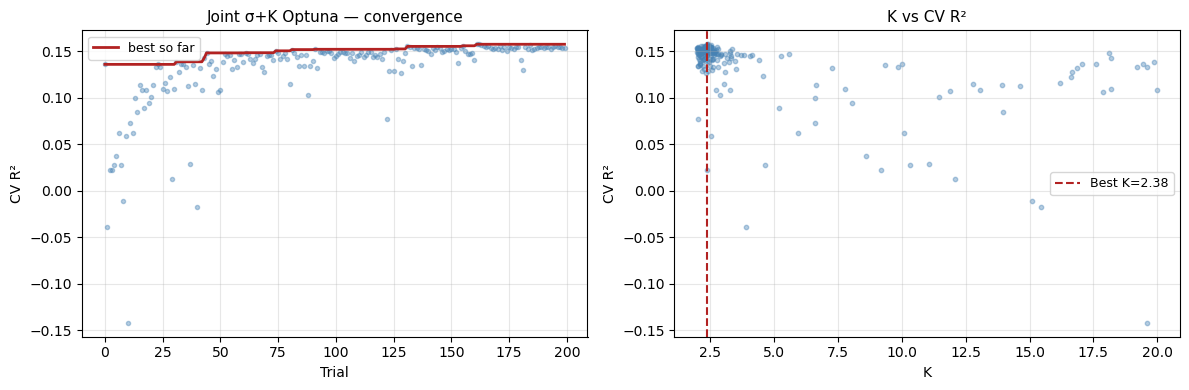

Saved fig/sweeps/sim_joint_optuna.png


In [20]:
if trials_df is not None and len(trials_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.plot(trials_df['number'], trials_df['value'], 'o', ms=3, alpha=0.4, color='steelblue')
    ax.plot(trials_df['number'], trials_df['value'].cummax(), '-', lw=2,
            color='firebrick', label='best so far')
    ax.set_xlabel('Trial', fontsize=10); ax.set_ylabel('CV R\u00b2', fontsize=10)
    ax.set_title('Joint \u03c3+K Optuna — convergence', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.scatter(trials_df['params_K'], trials_df['value'], s=10, alpha=0.4, color='steelblue')
    ax2.axvline(best_joint_K, color='firebrick', lw=1.5, ls='--',
                label=f'Best K={best_joint_K:.2f}')
    ax2.set_xlabel('K', fontsize=10); ax2.set_ylabel('CV R\u00b2', fontsize=10)
    ax2.set_title('K vs CV R\u00b2', fontsize=11)
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(fig_sweep / 'sim_joint_optuna.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print(f'Saved {fig_sweep}/sim_joint_optuna.png')

### 2b. Per-feature σ

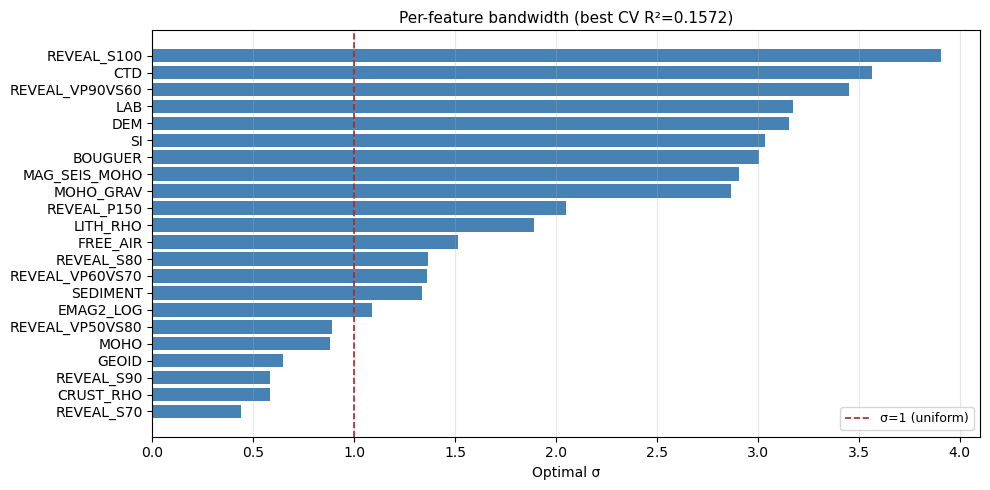

Saved fig/sweeps/sim_joint_sigma_bars.png


In [21]:
feats_sorted  = sorted(best_joint_sigmas, key=best_joint_sigmas.get)
sigmas_sorted = [best_joint_sigmas[f] for f in feats_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feats_sorted, sigmas_sorted, color='steelblue')
ax.axvline(1.0, color='firebrick', lw=1.2, ls='--', label='\u03c3=1 (uniform)')
ax.set_xlabel('Optimal \u03c3', fontsize=10)
ax.set_title(f'Per-feature bandwidth (best CV R\u00b2={best_joint_r2:.4f})', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(fig_sweep / 'sim_joint_sigma_bars.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'Saved {fig_sweep}/sim_joint_sigma_bars.png')

---
## 3. Evaluate & decide `obs_sel`

Quick LOO ablation with the best σ and K to rank features by importance.
Review the table, then **edit `obs_sel_final`** in §3b to select the features you want written to `sim_best_params.json`.

In [22]:
print(f'Running LOO ablation ({len(available)} features) ...')
t_loo_start = time.time()

r2_full = sim_cv_r2(
    X_sim, y_sim,
    np.array([best_joint_sigmas[f] for f in available], dtype=np.float32),
    best_joint_K, fold_splits, w=w_sim,
)
print(f'  Full model CV R\u00b2 = {r2_full:.4f}')

abl_rows = []
for i, feat in enumerate(available):
    idx_keep = [j for j in range(len(available)) if j != i]
    s_keep   = np.array([best_joint_sigmas[available[j]] for j in idx_keep], dtype=np.float32)
    r2_wo    = sim_cv_r2(X_sim[:, idx_keep], y_sim, s_keep, best_joint_K, fold_splits, w=w_sim)
    delta    = r2_wo - r2_full
    tag      = 'HELPFUL' if delta < -0.002 else ('HARMFUL' if delta > 0.002 else 'neutral')
    abl_rows.append(dict(feature=feat, r2_without=r2_wo, delta_r2=delta, verdict=tag,
                         sigma=best_joint_sigmas[feat]))
    print(f'  {i+1:2d}/{len(available)} drop {feat:28s} '
          f'R\u00b2={r2_wo:.4f} \u0394={delta:+.4f} {tag}')

abl_df  = pd.DataFrame(abl_rows).sort_values('delta_r2')
abl_csv = sweep_dir / 'sim_loo_ablation.csv'
abl_df.to_csv(abl_csv, index=False)
t_loo_end = time.time()
print(f'\nSaved {abl_csv}')
print(f'Wall time: {(t_loo_end - t_loo_start)/60:.1f} min')

Running LOO ablation (22 features) ...
  Full model CV R² = 0.1572
   1/22 drop SEDIMENT                     R²=0.1540 Δ=-0.0032 HELPFUL
   2/22 drop LITH_RHO                     R²=0.1564 Δ=-0.0008 neutral
   3/22 drop CTD                          R²=0.1571 Δ=-0.0001 neutral
   4/22 drop REVEAL_S80                   R²=0.1573 Δ=+0.0001 neutral
   5/22 drop REVEAL_P150                  R²=0.1563 Δ=-0.0010 neutral
   6/22 drop MAG_SEIS_MOHO                R²=0.1581 Δ=+0.0008 neutral
   7/22 drop REVEAL_S70                   R²=0.1496 Δ=-0.0076 HELPFUL
   8/22 drop REVEAL_S100                  R²=0.1573 Δ=+0.0000 neutral
   9/22 drop REVEAL_VP60VS70              R²=0.1579 Δ=+0.0006 neutral
  10/22 drop BOUGUER                      R²=0.1572 Δ=-0.0001 neutral
  11/22 drop MOHO_GRAV                    R²=0.1578 Δ=+0.0005 neutral
  12/22 drop REVEAL_VP50VS80              R²=0.1591 Δ=+0.0019 neutral
  13/22 drop GEOID                        R²=0.1376 Δ=-0.0196 HELPFUL
  14/22 drop MOHO      

### 3a. LOO ablation figure

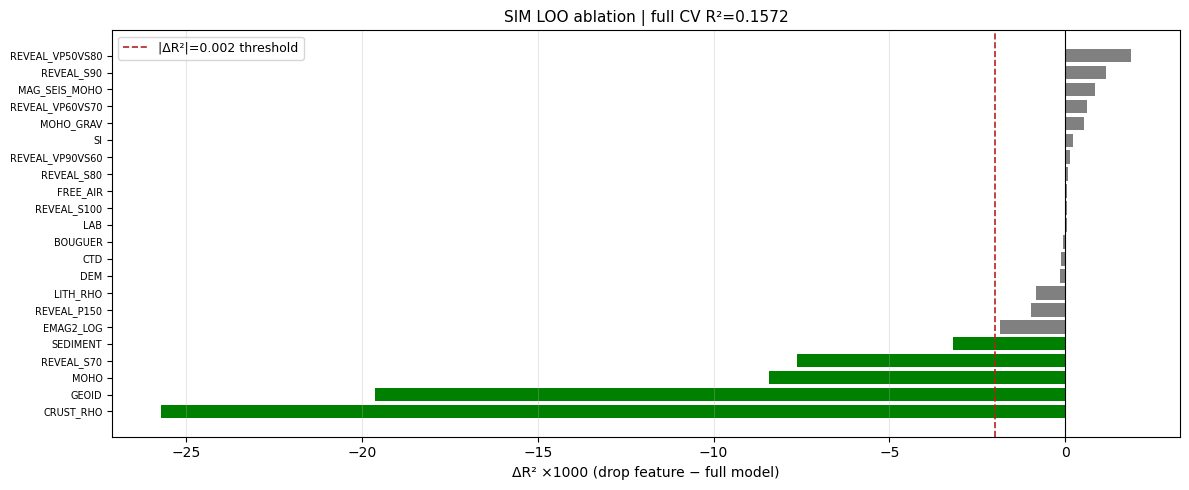

Saved fig/sweeps/sim_loo_ablation.png


In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['green' if v == 'HELPFUL' else ('firebrick' if v == 'HARMFUL' else 'grey')
          for v in abl_df['verdict']]
ax.barh(abl_df['feature'], abl_df['delta_r2'] * 1000, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(-2, color='firebrick', lw=1.2, ls='--', label='|\u0394R\u00b2|=0.002 threshold')
ax.set_xlabel('\u0394R\u00b2 \u00d71000 (drop feature \u2212 full model)', fontsize=10)
ax.set_title(f'SIM LOO ablation | full CV R\u00b2={r2_full:.4f}', fontsize=11)
ax.legend(fontsize=9); ax.tick_params(axis='y', labelsize=7); ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(fig_sweep / 'sim_loo_ablation.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print(f'Saved {fig_sweep}/sim_loo_ablation.png')

### 3b. Choose final feature list

Edit `obs_sel_final` below. Defaults to all HELPFUL + neutral features (excludes HARMFUL). After editing, run this cell then §4 to write the JSON.

In [24]:
# Auto-suggestion: keep HELPFUL + neutral; exclude HARMFUL
auto_keep = abl_df[abl_df['verdict'] != 'HARMFUL']['feature'].tolist()
print(f'Auto-suggested features to keep: {len(auto_keep)}')
for f in auto_keep:
    row = abl_df[abl_df['feature'] == f].iloc[0]
    print(f'  {f:28s}  \u0394R\u00b2={row["delta_r2"]:+.4f}  verdict={row["verdict"]}')

# ── EDIT THIS LIST if you want a custom selection ──────────────────────────
obs_sel_final = auto_keep  # or: obs_sel_final = ['FEATURE_A', 'FEATURE_B', ...]

# Verify R² of final selection
idx_final = [available.index(f) for f in obs_sel_final]
s_final   = np.array([best_joint_sigmas[f] for f in obs_sel_final], dtype=np.float32)
r2_final  = sim_cv_r2(X_sim[:, idx_final], y_sim, s_final, best_joint_K, fold_splits, w=w_sim)

print(f'\nFull model CV R\u00b2   : {r2_full:.4f} ({len(available)} features)')
print(f'Selected subset R\u00b2 : {r2_final:.4f} ({len(obs_sel_final)} features)')
print(f'\u0394 (subset \u2212 full)   : {r2_final - r2_full:+.4f}')

Auto-suggested features to keep: 22
  CRUST_RHO                     ΔR²=-0.0257  verdict=HELPFUL
  GEOID                         ΔR²=-0.0196  verdict=HELPFUL
  MOHO                          ΔR²=-0.0084  verdict=HELPFUL
  REVEAL_S70                    ΔR²=-0.0076  verdict=HELPFUL
  SEDIMENT                      ΔR²=-0.0032  verdict=HELPFUL
  EMAG2_LOG                     ΔR²=-0.0018  verdict=neutral
  REVEAL_P150                   ΔR²=-0.0010  verdict=neutral
  LITH_RHO                      ΔR²=-0.0008  verdict=neutral
  DEM                           ΔR²=-0.0001  verdict=neutral
  CTD                           ΔR²=-0.0001  verdict=neutral
  BOUGUER                       ΔR²=-0.0001  verdict=neutral
  LAB                           ΔR²=+0.0000  verdict=neutral
  REVEAL_S100                   ΔR²=+0.0000  verdict=neutral
  FREE_AIR                      ΔR²=+0.0001  verdict=neutral
  REVEAL_S80                    ΔR²=+0.0001  verdict=neutral
  REVEAL_VP90VS60               ΔR²=+0.0001  verd

---
## 4. Write `sim_best_params.json`

Writes best σ per feature, best K, and the chosen `obs_sel_final` list. Matches the GBM/QRF JSON pattern (`obs_sel`, `obs_model` fields).

In [25]:
sim_json = param_paths['sim']

sim_out = dict(
    model            = 'Similarity',
    sweep_notebook   = '3c_SIM_SWEEP',
    SIM_BEST_K       = float(best_joint_K),
    SIM_SIGMAS       = {f: float(best_joint_sigmas[f]) for f in obs_sel_final},
    SIM_KERNEL       = SIM_KERNEL,
    SIM_WEIGHT_MODE  = SIM_WEIGHT_MODE,
    OOD_WORST        = {
        'BOUGUER':         0.476,
        'REVEAL_VP60VS70': 0.451,
        'REVEAL_S80':      0.340,
        'DEM':             0.307,
        'REVEAL_VP90VS60': 0.315,
        'REVEAL_VP50VS80': 0.306,
        'REVEAL_S90':      0.301,
        'GEOID':           0.293,
        'LAB':             0.266,
        'MOHO_GRAV':       0.218,
        'REVEAL_S70':      0.226,
        'LITH_RHO':        0.214,
        'CTD':             0.201,
    },
    SIGMA_FLOOR_MIN  = 0.5,
    standardisation  = 'StandardScaler per CV fold (train fold only)',
    obs_sel          = obs_sel_final,
    obs_model        = obs_model,
    cv_r2_full       = float(r2_full),
    cv_r2_selected   = float(r2_final),
    cv_r2_joint_best = float(best_joint_r2),
    K_joint_bounds   = [K_JOINT_LO, K_JOINT_HI],
    SIM_SIGMA_BOUNDS = list(SIGMA_BOUNDS),  # per-feature sigma search range used (config.SIM_SIGMA_BOUNDS)
    n_optuna_trials  = N_OPTUNA_JOINT,
)

with open(sim_json, 'w') as fp:
    json.dump(sim_out, fp, indent=2)

print(f'Saved {sim_json}')
print(f'  SIM_BEST_K     : {sim_out["SIM_BEST_K"]:.4f}')
print(f'  obs_sel        : {len(obs_sel_final)} features')
print(f'  cv_r2_selected : {r2_final:.4f}')
for k, v in sim_out.items():
    if k not in ('SIM_SIGMAS', 'obs_sel', 'obs_model'):
        print(f'  {k:22s} {v}')

Saved output/sweeps/sim_best_params.json
  SIM_BEST_K     : 2.3756
  obs_sel        : 22 features
  cv_r2_selected : 0.1572
  model                  Similarity
  sweep_notebook         3c_SIM_SWEEP
  SIM_BEST_K             2.3755676944180437
  SIM_KERNEL             rbf
  SIM_WEIGHT_MODE        shifted_exp
  OOD_WORST              {'BOUGUER': 0.476, 'REVEAL_VP60VS70': 0.451, 'REVEAL_S80': 0.34, 'DEM': 0.307, 'REVEAL_VP90VS60': 0.315, 'REVEAL_VP50VS80': 0.306, 'REVEAL_S90': 0.301, 'GEOID': 0.293, 'LAB': 0.266, 'MOHO_GRAV': 0.218, 'REVEAL_S70': 0.226, 'LITH_RHO': 0.214, 'CTD': 0.201}
  SIGMA_FLOOR_MIN        0.5
  standardisation        StandardScaler per CV fold (train fold only)
  cv_r2_full             0.15724776983261107
  cv_r2_selected         0.15724776983261107
  cv_r2_joint_best       0.15724776983261107
  K_joint_bounds         [2.0, 20.0]
  SIM_SIGMA_BOUNDS       [0.25, 4.0]
  n_optuna_trials        200


---
## 5. Runtime log

In [26]:
def _safe(x):
    try: return float(x)
    except: return None

log_df = pd.DataFrame([
    dict(stage='sim_joint_optuna',
         wall_s=_safe(locals().get('t_joint_end', 0) - locals().get('t_joint_start', 0))),
    dict(stage='sim_loo_ablation',
         wall_s=_safe(locals().get('t_loo_end', 0) - locals().get('t_loo_start', 0))),
])
log_df['wall_min'] = (log_df['wall_s'] / 60).round(2)
log_df.to_csv(sweep_dir / 'sim_runtime_log.csv', index=False)
print(log_df[['stage', 'wall_min']].to_string(index=False))
print(f'Saved {sweep_dir}/sim_runtime_log.csv')

           stage  wall_min
sim_joint_optuna    140.79
sim_loo_ablation     13.68
Saved output/sweeps/sim_runtime_log.csv
